# Annual water balance (P - PET) of the Western Cape, South Africa

## Introduction

This page shows a reproducable R script code for the Western Cape's annual water balance, which is calculated by subtracting the annual potential evapotranspiration from the annual precipitation (P - PET). The annual water balance is a fundamental climatological and hydrological metric representing the net water surplus or deficit at a specific site or within a catchment over a year. It is used to characterise climate aridity and determine water availability for agriculture, ecosystem health, and water resource management. Based on the data from 2000-2012, the annual water balance of South Africa has been consistantly in deficit, with an average annual rainfall of approximately 450-464 mm and a significantly higher rate of potential evapotranspiration, making it a water-scarce country.

The workflow is fairly simple and I hope you can follow the logic behind it from raw climate surfaces to a final map. The PET estimator used in this workflow is **Thornthwaite** (temperature + latitude), because it is transparent and easy to compute using the WorldClim monthly mean temperature. I will show how to compute the monthly PET and then annual PET so that the water balance metric is at least (or hopefully) phydically meaningful for broad hydrological and ecological interpretation.

## Packages used

- `geodata` — Download WorldClim monthly temperature and precipitation and GADM country and provincial boundaries.
- `terra` — Raster import, cropping, masking and raster reconstruction.
- `sf` — Vector (country boundary) handling and plotting overlays.
- `SPEI` — Thornthwaite PET implementation.
- `tidyverse` — Tidy data handling, reshaping, and visualisation.
- `colorspace` — Colour palettes for continuous maps.


Before we begin with the analyses, I first want to prevent warning messages from appearing on my code block. *This method can be ignored when you are using RStudio or base R to do your coding. I am only using it because I am using an R kernel in Jupyter Notebook.*

In [3]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

options(
  repr.plot.width  = 10,
  repr.plot.height = 7,
  repr.plot.res    = 150
)

# These options center our plots and gives them a better resolution than default. 
# These options are only for jupyter notebook. Ignore you use R and RStudio.

### Install packages

Before we begin with the analysis, we first have to install the required packages. **Make sure to install the packages you have not previously installed, and exclude those you have in the installation.**

In [ ]:
install.packages("geodata")
install.packages("terra")
install.packages("sf")
install.packages("SPEI")
install.packages("tidyverse")
install.packages("colorspace")

### Load libraries

In [4]:
# Load libraries
library(terra)
library(sf)
library(geodata)
library(SPEI)
library(tidyverse)
library(colorspace)
options(scipen = 10) # Avoid scientific notation in outputs

### Data acquisition

Now that our libraries have been loaded, we will now download South Africa's boundary via `geodata` as well as the monthly mean temperature (`tavg`) and monthly precipitation (`prec`).

**_This step might take a bit of time to run because we are downloading a lot of high resolution data, please be patient with your computer._**

In [5]:
# Download South Africa boundary

south_africa_boundary <- geodata::gadm(country = "ZAF", level = 0, path = tempdir())

# Convert boundary to sf for plotting

south_africa_sf   <- st_as_sf(south_africa_boundary)

# Download WorldClim global monthly temperature and precipitation

temperature_global <- geodata::worldclim_global(var = "tavg", res = 2.5, path = tempdir())
precipitation_global <- geodata::worldclim_global(var = "prec",  res = 2.5, path = tempdir())

### Spatial preparation

Next we will crop and mask the global temperature and precipitation layers to South Africa. This ensures that the map does not show any information outside South Africa's boundary. **_(You can skip this part unless you are planning to use the entirety of South Africa)_**

In [ ]:
# Crop and mask global raster layers to South Africa

temperature_sa  <- crop(temperature_global, south_africa_boundary) %>% mask(south_africa_boundary)
precipitation_sa  <- crop(precipitation_global, south_africa_boundary) %>% mask(south_africa_boundary)

Just so that we do not confuse ourselves at a later stage, we will rename the layers by months:

In [19]:
# Name layers by month for clarity

month_names <- month.abb
names(temperature_sa) <- month_names
names(precipitation_sa)  <- month_names

The goal is to map out a single province from South Africa, and an example province I will use is the Western Cape province. So we will also have to download its boundary for use:

In [22]:
# Download provincial boundaries

zaf_admin1 <- geodata::gadm(country = "ZAF", level = 1, path = tempdir())
zaf_admin1_sf <- st_as_sf(zaf_admin1)

# Pick province by NAME_1; you can change to any South African province you want.
western_cape <- "Western Cape"
western_cape_sf <- zaf_admin1_sf %>% filter(NAME_1 == western_cape)

From there onwards we are going to crop the global SA rasters to the province extent for efficiency. We keep the same CRS/geometry as the SA raster objects. **_If you ended up skipping the section where you crop the rasters to South Africa, you can begin here in clipping directly to the province you set. However, make sure you set your global rasters as inputs to crop and not the SA cropped rasters._**

In [23]:
# Crop SA rasters to Western Cape province

temperature_prov <- crop(temperature_sa, western_cape_sf) %>% mask(western_cape_sf)
precipitation_prov <- crop(precipitation_sa, western_cape_sf) %>% mask(western_cape_sf)

### Compute monthly PET (Thornthwaite) and aggregate to annual PET and P

We compute Thornthwaite monthly PET for each cell using its latitude (`y`), sum monthly PET to annual PET, sum monthly P to annual P, then compute annual water balance = P_annual - PET_annual.


We are going to make a helper function to compute **Thornthwaite** monthly PET (returns 12 values in mm):

In [24]:
# Create a latitude raster (same geometry as the temperature raster)

latitude_rast <- init(temperature_prov, fun = "y")   # terra::init with "y" makes a raster of y (lat) values

# Stack temperatures + latitude so terra::app gets both in the same vector (Order: T_Jan -> T_Dec, LAT)

temp_plus_lat <- c(temperature_prov, latitude_rast)

# Define the per‑cell function to produce annual PET

thornthwaite_annual_sum <- function(v) {
  if (all(is.na(v[1:12]))) return(NA_real_)            # v may contain NAs. If the monthly temps are all NA -> return NA
  temps <- v[1:12]
  lat   <- v[13]
  pet_monthly <- SPEI::thornthwaite(temps, lat = lat)  # Compute monthly PET (SPEI::thornthwaite) and sum to annual PET
  if (all(is.na(pet_monthly))) return(NA_real_)        # If somehow PET returned NA for all months, guard by returning NA
  sum(pet_monthly, na.rm = TRUE)
}

# Run terra::app — this is efficient (C loop) and avoids rowwise R evaluation
pet_annual_rast <- app(temp_plus_lat, fun = thornthwaite_annual_sum)

[1] "Checking for missing values (`NA`): all the data must be complete. Input type is vector. Assuming the data are monthly time series starting in January, all regular (non-leap) years."
[1] "Checking for missing values (`NA`): all the data must be complete. Input type is vector. Assuming the data are monthly time series starting in January, all regular (non-leap) years."
[1] "Checking for missing values (`NA`): all the data must be complete. Input type is vector. Assuming the data are monthly time series starting in January, all regular (non-leap) years."
[1] "Checking for missing values (`NA`): all the data must be complete. Input type is vector. Assuming the data are monthly time series starting in January, all regular (non-leap) years."
[1] "Checking for missing values (`NA`): all the data must be complete. Input type is vector. Assuming the data are monthly time series starting in January, all regular (non-leap) years."
[1] "Checking for missing values (`NA`): all the data must b

We will now compute annual precipitation and water balance:

In [26]:
# Sum the 12 precipitation layers to an annual precipitation raster
precipitation_annual_rast <- terra::app(precipitation_prov, fun = function(v) sum(v, na.rm = TRUE))

# Compute water balance (P - PET), cellwise
water_balance_rast <- precipitation_annual_rast - pet_annual_rast

# Optional: mask to province (it should already be masked) but just to be safe:
water_balance_rast <- mask(water_balance_rast, western_cape_sf)

Annual precipitation is the sum of the 12 monthly precip layers. Water balance (P − PET) is a simple, interpretable metric: positive values indicate surplus water (precipitation exceeds atmospheric demand) and negative values indicate deficit.

### Prepare data for plotting

`ggplot2` inside the `tidyverse` package requires a tabular structure. We will have to convert raster cells to a data frame before we begin to plot.

In [28]:
# Convert to data.frame for ggplot (drop NA cells to keep the plotting small)
df_plot <- as.data.frame(water_balance_rast, xy = TRUE, na.rm = TRUE)
colnames(df_plot)[3] <- "water_balance_mm"

# A quick statistical summary (inspect)
summary(df_plot$water_balance_mm)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -835.8  -603.2  -484.6  -465.0  -360.8   130.8 

### Plot the map

Since we are making a provincial level map, I think it would be beneficial to add an inset map to the main one to show where the Western Cape province lies in the country.

In [33]:
inset_plot <- ggplot() +
  geom_sf(data = south_africa_sf, fill = "gray90", colour = "gray60", size = 0.15) +   # whole country background
  geom_sf(data = western_cape_sf, fill = "#E41A1C", colour = "black", size = 0.3, alpha = 0.7) + # highlighted province

  # small border and minimal theme, no axes/ticks

  coord_sf(expand = FALSE) +
  theme_void() +
  theme(panel.background = element_rect(fill = "white", colour = "black", size = 0.35), plot.margin = margin(2, 2, 2, 2))

In [34]:
main_plot <- ggplot() +

# Add water balance raster

geom_raster(data = df_plot, aes(x = x, y = y, fill = water_balance_mm)) +

# Add western Cape boundary

geom_sf(data = western_cape_sf, fill = NA, colour = "black", size = 0.3) +

# Add map coordinates

coord_sf(expand = FALSE) +

# Add colour gradient to map

scale_fill_continuous_diverging(palette = "Blue-Red", mid = 0, name = "Annual water balance (mm)\n(P - PET)") +

# Add map labels

labs(title = paste0("Annual water balance (P - PET) — ", western_cape), subtitle = "Positive = wet (P > PET), Negative = dry (P < PET)",
    caption = "Data source: WorldClim v2 (geodata). PET: Thornthwaite (SPEI)") +

# Add map themes

theme_minimal(base_size = 12) + 
theme(panel.grid = element_blank(), axis.title = element_blank())

Now that the inset plot and the main plot have been made, we can combine the two to make our final map:

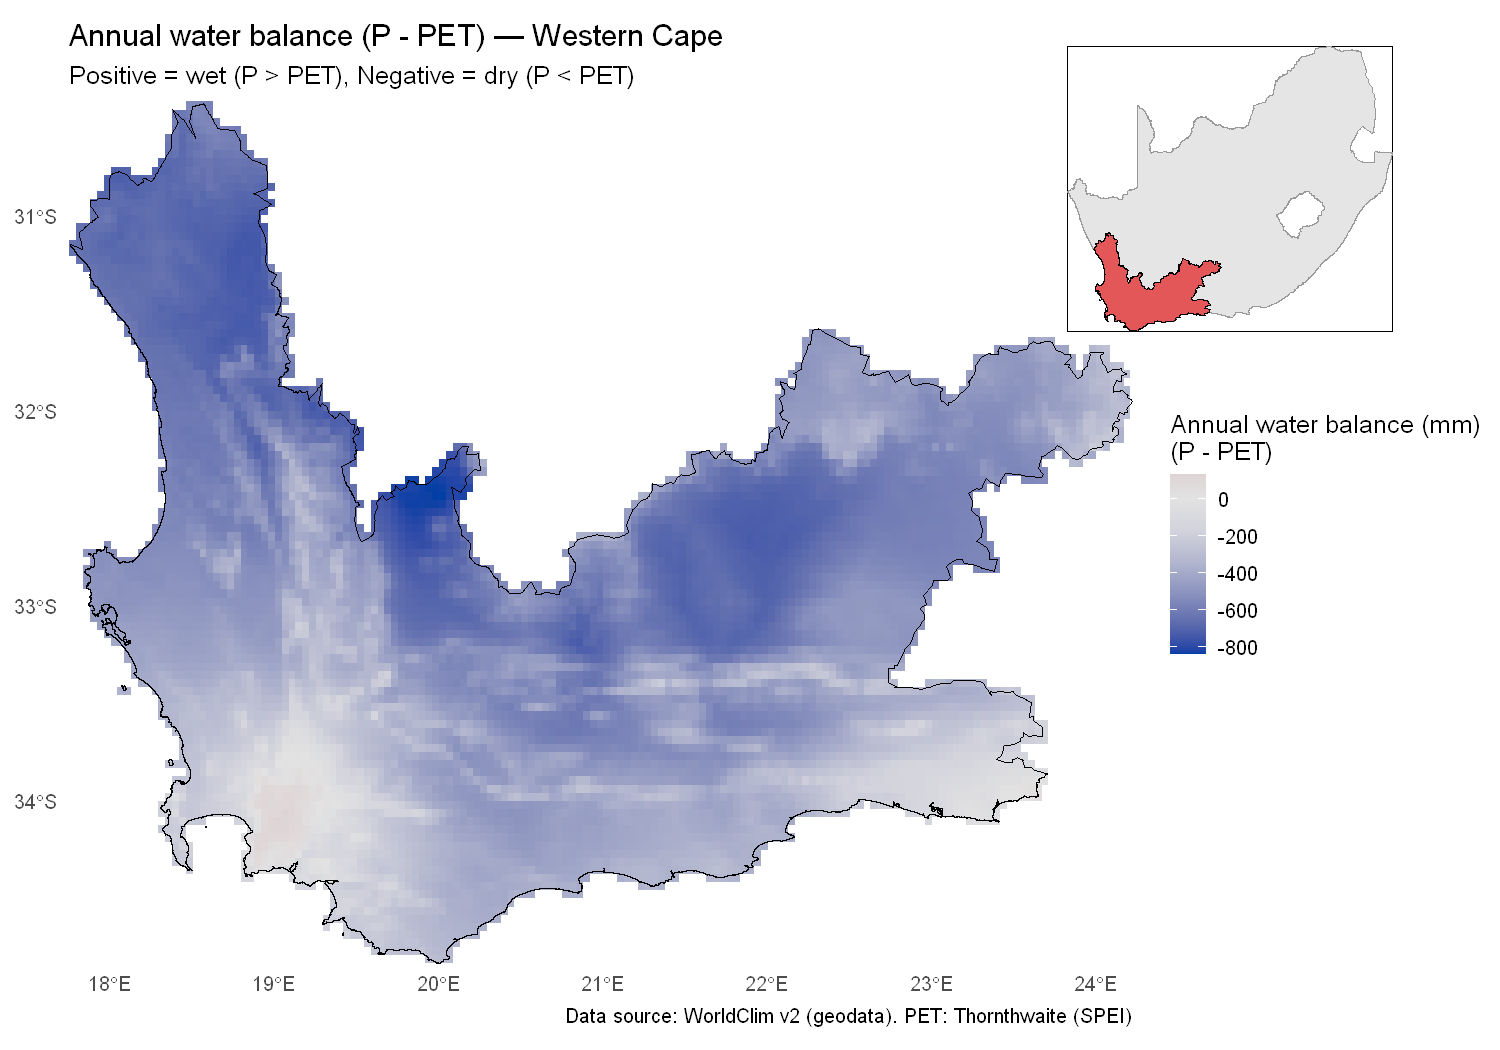

In [38]:
library(cowplot) # Library for ggdraw and draw_plot

final_plot <- ggdraw() +
  draw_plot(main_plot,   x = 0,   y = 0,   width = 1,   height = 1) +
  draw_plot(inset_plot,  x = 0.68, y = 0.68, width = 0.28, height = 0.28)  # top-right inset

# Print the combined figure

print(final_plot)

### Interpretation

Just as stated in the introduction section of this page, South Africa has been in a constant annual water defict. This can be seen by this on this map of the Western Cape province, where the net annual water deficit is shown in cool colours (blue). The balance ranged roughly from zero all the way down to -800 mm per year. Only the coastal band and a few local lowland areas appraoch neutral or slightly positive values (pale/white colours), while the interior and many upland parts are strongly negative (darker shade of blue). In hydrological terms, this means that for large parts of the Western Cape, the annual evapotranspiration exceeds the rainfall - rainfall is not sufficient to meet the atmospheric demand - so they have limited annual surface/soil water surplus. 

If I were to use my knowledge on the ecology of the Western Cape, I would say the areas where the annual water balance approaches zero, support fynbos and other mesic communities that depend on winter rainfall and on catchment recharge, while the strongly negative annual water balance areas and northern areas correspond to renosterveld amd drier shrubland communities that are drought-tolerant, deep rooted, and succulents. 

This is just a broad interpretation of the map, and it is just an annual, climate-scale water balance... It says nothing about runoff, soil moisture or irrigation and PET here was estimated with a temperature-based Thornthwaite method, so when you do local hydrological assessments, I would advice you to use site data or more mechanistic PET estimates where possible 

**_Thank you for your time_**